# Trigger rates from database

Gianluca Petrillo (petrillo@slac.stanford.edu)

Thu 13 Mar 2025

In [1]:
import numpy
import matplotlib.pyplot as plt
import pandas
import time

In [2]:
TriggerDatabaseFile = 'TriggerDatabase-NoCalib-5145B67C-20260505.pickle.gz'

In [3]:
%%time
TrigDB = pandas.read_pickle(TriggerDatabaseFile)
TrigDB.info()
RunList = sorted(TrigDB.run_number.unique())
print(f"Loaded {len(TrigDB)} triggers in {len(RunList)} runs"
      f" between {TrigDB.run_number.iloc[0]} ({time.ctime(TrigDB.beam_timestamp.iloc[0]/1e9)})"
      f" and {TrigDB.run_number.iloc[-1]} ({time.ctime(TrigDB.beam_timestamp.iloc[-1]/1e9)})."
)

<class 'pandas.DataFrame'>
RangeIndex: 38947480 entries, 0 to 38947479
Data columns (total 14 columns):
 #   Column               Dtype
---  ------               -----
 0   run_number           int64
 1   event_no             int64
 2   gate_type            int64
 3   trigger_type         int64
 4   trigger_source       int64
 5   gate_id              int64
 6   gate_id_bnb          int64
 7   gate_id_numi         int64
 8   gate_id_bnboff       int64
 9   gate_id_numioff      int64
 10  wr_timestamp         int64
 11  beam_timestamp       int64
 12  enable_timestamp     int64
 13  triggerFromBeamGate  int64
dtypes: int64(14)
memory usage: 4.1 GB
Loaded 38947480 triggers in 1633 runs between 8836 (Tue Aug 23 09:54:14 2022) and 14244 (Fri May  1 21:38:00 2026).
CPU times: user 7.34 s, sys: 2.02 s, total: 9.36 s
Wall time: 9.41 s


In [4]:
print(f"Loaded {len(TrigDB)} triggers in {len(RunList)} runs"
      f" between {TrigDB.run_number.iloc[0]} ({time.ctime(TrigDB.beam_timestamp.iloc[0]/1e9)})"
      f" and {TrigDB.run_number.iloc[-1]} ({time.ctime(TrigDB.beam_timestamp.iloc[-1]/1e9)})."
)

Loaded 38947480 triggers in 1633 runs between 8836 (Tue Aug 23 09:54:14 2022) and 14244 (Fri May  1 21:38:00 2026).


### Library functions

In [5]:
def savefig(name, fig = None, formats = ( ".png", ".pdf", ) ):
    """Saves the specified figure (or the current one) into image files with the specified base name."""
    if fig is None: fig = plt
    try:
        if RunTag: name = f"{RunTag}-{name}"
    except NameError: pass
    for suffix in formats: fig.savefig(name + (suffix if suffix.startswith('.') else '.' + suffix))

### Trigger profiles

Some general settings to make the following plots more automated and consistent.
 * `GateNames` lists the name of the gates we data about
 * `SignalBeams` lists the name of the beams we have signal data about (`'BNB'`, `'NuMI'`)

In [6]:
BeamInfo = {
    'BNB':         dict(name='BNB',         beamName='BNB',         color=('mediumblue',   0.4), sourceIndex=1, reference={ 'spill': 1.6, 'rate': 4.0,    'POT/spill': 3.5e12 }, veto=4.0, hasSignal=True,  scale=1.0),
    'NuMI':        dict(name='NuMI',        beamName='NuMI',        color=('orange',       0.4), sourceIndex=2, reference={ 'spill': 9.5, 'rate': 0.9375, 'POT/spill': 4.0e13 }, veto=4.0, hasSignal=True,  scale=1.0),
    'BNBoffbeam':  dict(name='BNBoffbeam',  beamName='BNB',         color=('forestgreen',  0.4), sourceIndex=3, reference={ 'spill': 1.6, 'rate': 4.0,    'POT/spill': 3.5e12 }, veto=4.0, hasSignal=False, scale=1.0),
    'NuMIoffbeam': dict(name='NuMIoffbeam', beamName='NuMI',        color=('firebrick',    0.4), sourceIndex=4, reference={ 'spill': 9.5, 'rate': 0.9375, 'POT/spill': 4.0e13 }, veto=4.0, hasSignal=False, scale=1.0),
    'calibration': dict(name='calibration', beamName='calibration', color=('mediumpurple', 0.4), sourceIndex=5, reference={ 'spill': 1.6, 'rate': 1.00,   'POT/spill': 0.0  },   veto=4.0, hasSignal=False, scale=1.0),
}
GateNames = [ 'BNB', 'BNBoffbeam', 'NuMI', 'NuMIoffbeam', 'calibration' ] # here for the order
SignalBeams = [ beamName for beamName, beamInfo in BeamInfo.items() if beamInfo['hasSignal'] and (TrigDB.gate_type == beamInfo['sourceIndex']).any() ]

In [7]:
gateToName = [ None ] * (len(BeamInfo) + 1)
for beamInfo in BeamInfo.values(): gateToName[beamInfo['sourceIndex']] = beamInfo['name']

In [8]:
beamToOnbeamGate = numpy.zeros(len(GateNames)+1).astype(int)
beamToOffbeamGate = numpy.zeros(len(GateNames)+1).astype(int)
for beamInfo in BeamInfo.values():
    (beamToOnbeamGate if beamInfo['hasSignal'] else beamToOffbeamGate)[BeamInfo[beamInfo['beamName']]['sourceIndex']] = beamInfo['sourceIndex']

for beamName in SignalBeams:
    beam_type = BeamInfo[beamName]['sourceIndex']
    print(f"{beamName} (#{beam_type}) has on-beam stream {gateToName[beamToOnbeamGate[beam_type]]} ({beamToOnbeamGate[beam_type]})"
          f" and off-beam stream {gateToName[beamToOffbeamGate[beam_type]]} ({beamToOffbeamGate[beam_type]}).")

BNB (#1) has on-beam stream BNB (1) and off-beam stream BNBoffbeam (3).
NuMI (#2) has on-beam stream NuMI (2) and off-beam stream NuMIoffbeam (4).


In [28]:
RunPeriods = {
    'Run1':       dict(tag='Run1', name='ICARUS Run1', firstRun= 8460,  lastRun= 8554, prescale=dict(BNB=200, NuMI=60, BNBoffbeam=20, NuMIoffbeam=20), color='teal'       ),
    'Run2':       dict(tag='Run2', name='ICARUS Run2', firstRun= 9301,  lastRun=10097, prescale=dict(BNB=200, NuMI=60, BNBoffbeam=20, NuMIoffbeam=20), color='orange'     ),
    'Run3':       dict(tag='Run3', name='ICARUS Run3', firstRun=11806,  lastRun=12037, prescale=dict(BNB= 40, NuMI=30, BNBoffbeam=20, NuMIoffbeam=20), color='forestgreen'),
    'Run4':       dict(tag='Run4', name='ICARUS Run4', firstRun=12962,  lastRun=13272, prescale=dict(BNB= 40, NuMI=30, BNBoffbeam=20, NuMIoffbeam=20), color='purple'     ),
    'Run5':       dict(tag='Run5', name='ICARUS Run5', firstRun=13758,  lastRun=99999, prescale=dict(BNB= 40, NuMI=30, BNBoffbeam=20, NuMIoffbeam=20), color='navy'    ),
    # "preparation" included changes in trigger (adders), beam gate delays, minimum bias prescale
    'Run3prep':   dict(tag='Run3prep',   name='ICARUS Run3 preparation (to 2024-03-30)', firstRun=11806, lastRun=11834, prescale=dict(BNB=200, NuMI=60, BNBoffbeam=20, NuMIoffbeam=20)), # before the change of beam gate delays
    'Run3stable': dict(tag='Run3stable', name='ICARUS Run3 (2024-03-30 on)',             firstRun=11835, lastRun=12037, prescale=dict(BNB= 40, NuMI=30, BNBoffbeam=20, NuMIoffbeam=20)), # after the change of beam gate delays
}

This array maps the gate type index to the beam (BNB or NuMI), expressed as the type of the on-beam gate:

In [19]:
GateToBeamMap = numpy.zeros(max(info['sourceIndex'] for info in BeamInfo.values()) + 1, dtype=int)
for info in BeamInfo.values(): GateToBeamMap[info['sourceIndex']] = BeamInfo[info['beamName']]['sourceIndex']

Discover the gate content of our data:

In [20]:
AvailableGates = sorted(TrigDB.gate_type.unique().astype(int))
AvailableBeams = sorted(numpy.unique(GateToBeamMap[TrigDB.gate_type]).astype(int))
print(f"Data has {len(AvailableGates)} gates:", ", ".join(map(gateToName.__getitem__, AvailableGates)))
print(f"Data has {len(AvailableBeams)} beams:", ", ".join(map(gateToName.__getitem__, AvailableBeams)))

Data has 4 gates: BNB, NuMI, BNBoffbeam, NuMIoffbeam
Data has 2 beams: BNB, NuMI


Data is organized per run, with one column dedicated to each gate type.
This makes it easier to compare on-beam and off-beam rates.
Each run includes its start and end timestamps (first and last triggered event in the run), the run duration in seconds, and the number of recorded events.

In [21]:
RunInfo = TrigDB.groupby('run_number').agg(
    startTimeStamp=pandas.NamedAgg('beam_timestamp', min),
    endTimeStamp=pandas.NamedAgg('beam_timestamp', max),
    events=pandas.NamedAgg('beam_timestamp', len),
)
RunInfo['duration'] = (RunInfo.endTimeStamp - RunInfo.startTimeStamp) / 1e9

Add a column for each gate type (`<gate type>_events`) with the number of light-triggered events collected for that gate type.

In [22]:
RunStats = (
    pandas.concat(
        [ RunInfo ] + [
            gateData.groupby('run_number').apply(len).to_frame(gateToName[gate_type] + '_events') for gate_type, gateData in TrigDB[TrigDB.trigger_type == 0].groupby('gate_type')
        ],
        axis='columns'
    ).fillna(0).astype(int) # some runs don't have any event in a certain gate, which turns the value into a n/a and the column into a Pandas float
    .reset_index() # `run_number` back to a normal column
)

Also add the excess of beam-induced events. Should be positive...

In [23]:
for beamName in SignalBeams:
    RunStats[beamName + '_excess_events'] = RunStats[beamName + '_events'] - RunStats[beamName + 'offbeam_events']

Now add average event rates:

In [24]:
for streamName in [ gateToName[name] for name in AvailableGates ] + [ name + '_excess' for name in SignalBeams ]:
    RunStats[streamName + '_rate'] = (RunStats[streamName + '_events'] - 1) / RunStats.duration

In [25]:
RunStats

,run_number,startTimeStamp,endTimeStamp,events,duration,BNB_events,NuMI_events,BNBoffbeam_events,NuMIoffbeam_events,BNB_excess_events,NuMI_excess_events,BNB_rate,NuMI_rate,BNBoffbeam_rate,NuMIoffbeam_rate,BNB_excess_rate,NuMI_excess_rate
0,8836,1661273654555094648,1661315740033261640,4318,42085,1030,0,1001,0,29,0,0.024451,-0.000024,0.023761,-0.000024,0.000665,-0.000024
1,8889,1662693210585355992,1662733059137968912,3974,39848,896,0,912,0,-16,0,0.022460,-0.000025,0.022862,-0.000025,-0.000427,-0.000025
2,8977,1665693838524206240,1665693862515034192,3,23,0,0,1,0,-1,0,-0.043478,-0.043478,0.000000,-0.043478,-0.086957,-0.043478
3,8978,1665695286157122768,1665697086345755096,553,1800,126,0,138,0,-12,0,0.069444,-0.000556,0.076111,-0.000556,-0.007222,-0.000556
4,8979,1665698870488543728,1665698990493660592,67,120,21,0,12,0,9,0,0.166667,-0.008333,0.091667,-0.008333,0.066667,-0.008333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1628,14228,1777309406022004896,1777313683582493896,2959,4277,803,0,551,0,252,0,0.187515,-0.000234,0.128595,-0.000234,0.058686,-0.000234
1629,14240,1777656649827260928,1777656689815905936,7,39,3,0,0,0,3,0,0.051282,-0.025641,-0.025641,-0.025641,0.051282,-0.025641
1630,14241,1777657306692098720,1777657592624333184,44,285,12,0,11,0,1,0,0.038596,-0.003509,0.035088,-0.003509,0.000000,-0.003509
1631,14242,1777658266631901264,1777658526662962272,35,260,7,0,7,0,0,0,0.023077,-0.003846,0.023077,-0.003846,-0.003846,-0.003846


In [26]:
runToStart = lambda run: RunStats.startTimeStamp.iloc[RunStats.run_number.searchsorted(run)]
for periodInfo in RunPeriods.values():
    print(f"{periodInfo['name']} started with run {periodInfo['firstRun']} on {time.ctime(runToStart(periodInfo['firstRun'])/1e9)}")

ICARUS Run1 started with run 8460 on Tue Aug 23 09:54:14 2022
ICARUS Run2 started with run 9301 on Tue Dec 20 15:50:09 2022
ICARUS Run3 started with run 11806 on Thu Mar 14 15:25:06 2024
ICARUS Run4 started with run 12962 on Tue Dec 10 15:26:43 2024
ICARUS Run5 started with run 13758 on Thu Oct 16 15:26:32 2025
ICARUS Run3 preparation (to 2024-03-30) started with run 11806 on Thu Mar 14 15:25:06 2024
ICARUS Run3 (2024-03-30 on) started with run 11835 on Sat Mar 30 08:19:56 2024


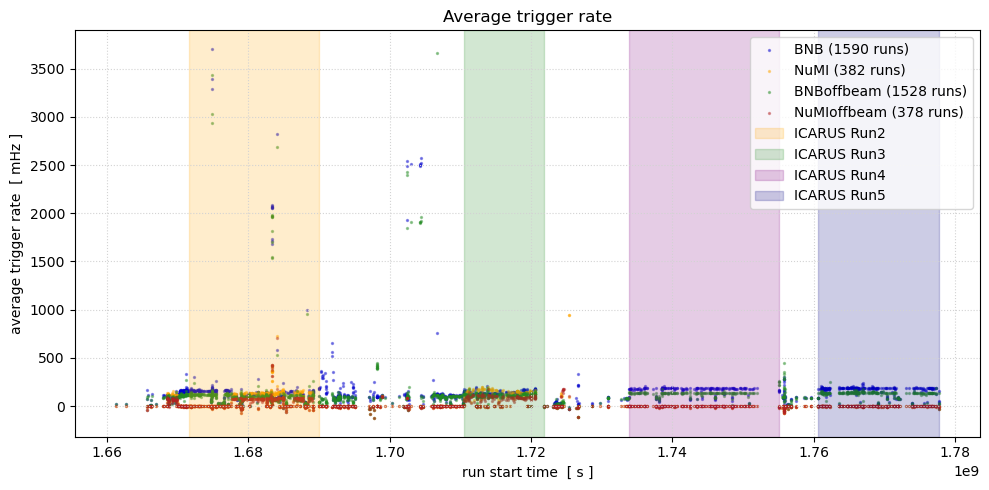

In [29]:
fig, ax = plt.subplots(layout='tight', figsize=(10, 5))
for gate_type in AvailableGates:
    gateName = gateToName[gate_type]
    ax.scatter(
        RunStats.startTimeStamp / 1e9, RunStats[gateName + '_rate'] * 1000.0,
        label=f"{gateName} ({sum(RunStats[gateName + '_events'].astype(bool))} runs)",
        s=2, color=BeamInfo[gateName]['color'],
    )
for periodInfo in RunPeriods.values():
    if 'color' not in periodInfo: continue
    if periodInfo['firstRun'] > RunStats.iloc[-1].run_number: continue
    if periodInfo['lastRun'] <= RunStats.iloc[0].run_number: continue
    periodStart = runToStart(periodInfo['firstRun'])/1e9
    periodEnd = (runToStart(periodInfo['lastRun'] + 1) if (periodInfo['lastRun'] < RunStats.iloc[-1].run_number) else RunStats.iloc[-1].endTimeStamp)/1e9
    ax.axvspan(periodStart, periodEnd, color=( periodInfo['color'], 0.2 ), label=periodInfo['name'])
ax.set(
    title="Average trigger rate",
    xlabel="run start time  [ s ]",
    ylabel="average trigger rate  [ mHz ]",
)
ax.grid('x', color='lightgray', linestyle=':')
ax.legend()
savefig("AverageTriggerRate", fig)

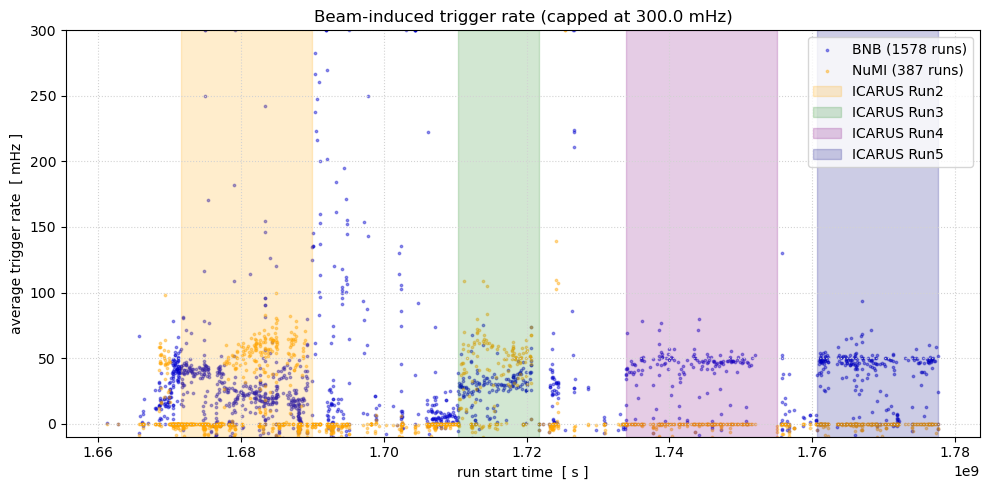

In [30]:
CapRateAt = 0.300 # mHz
fig, ax = plt.subplots(layout='tight', figsize=(10, 5))
for beam_type in AvailableBeams:
    beamName = gateToName[beam_type]
    ax.scatter(
        RunStats.startTimeStamp / 1e9, numpy.fmin(RunStats[beamName + '_excess_rate'], CapRateAt) * 1000.0,
        label=f"{beamName} ({sum(RunStats[beamName + '_excess_events'].astype(bool))} runs)",
        s=3, color=BeamInfo[beamName]['color'],
    )
for periodInfo in RunPeriods.values():
    if 'color' not in periodInfo: continue
    if periodInfo['firstRun'] > RunStats.iloc[-1].run_number: continue
    if periodInfo['lastRun'] <= RunStats.iloc[0].run_number: continue
    periodStart = runToStart(periodInfo['firstRun'])/1e9
    periodEnd = (runToStart(periodInfo['lastRun'] + 1) if (periodInfo['lastRun'] < RunStats.iloc[-1].run_number) else RunStats.iloc[-1].endTimeStamp)/1e9
    ax.axvspan(periodStart, periodEnd, color=( periodInfo['color'], 0.2 ), label=periodInfo['name'])
ax.set(
    title=f"Beam-induced trigger rate (capped at {CapRateAt*1000.0} mHz)",
    xlabel="run start time  [ s ]",
    ylabel="average trigger rate  [ mHz ]",
    ylim=( -10.0, CapRateAt * 1000.0), # mHz
)
ax.grid('x', color='lightgray', linestyle=':')
ax.legend()
savefig("BeamInducedTriggerRate", fig)

In extracting the following statistics, we exclude runs that are too short (< 30').

In [31]:
for period, info in RunPeriods.items():
    periodData = RunStats[RunStats.run_number.between(info['firstRun'], info['lastRun']) & (RunStats.duration >= 1800.0)]
    if periodData.empty: continue
    print(f"{info['name']:12} ({len(periodData):3} runs between {periodData.run_number.iloc[0]:5d} and {periodData.run_number.iloc[-1]:5d}) excess events:", end='')
    for beam_type in AvailableBeams:
        beamData = periodData[
            (periodData[gateToName[beamToOnbeamGate[beam_type]] + '_events'] >= 100)
            & (periodData[gateToName[beamToOffbeamGate[beam_type]] + '_events'] >= 100)
        ]
        if beamData.empty: continue
        beamStats = dict(
            runs=len(periodData), # qualifying runs
            events=sum(periodData[gateToName[beamToOnbeamGate[beam_type]] + '_excess_events']),
            duration=sum(periodData.duration),
        )
        print(f" {gateToName[beam_type]}: {beamStats['events']/beamStats['duration']*1000:4.1f} mHz ({beamStats['events']:6d} events from {beamStats['runs']:3d} runs)", end='')
    # for beam
    print('.')
# for run period


ICARUS Run2  (259 runs between  9301 and 10097) excess events: BNB: 28.1 mHz (391171 events from 259 runs) NuMI: 31.0 mHz (431244 events from 259 runs).
ICARUS Run3  (130 runs between 11806 and 12037) excess events: BNB: 30.6 mHz (274950 events from 130 runs) NuMI: 44.0 mHz (395376 events from 130 runs).
ICARUS Run4  (131 runs between 12962 and 13271) excess events: BNB: 46.2 mHz (753940 events from 131 runs).
ICARUS Run5  (181 runs between 13758 and 14244) excess events: BNB: 45.8 mHz (591566 events from 181 runs).
ICARUS Run3 preparation (to 2024-03-30) ( 20 runs between 11806 and 11834) excess events: BNB: 27.7 mHz ( 36439 events from  20 runs) NuMI: 30.4 mHz ( 39993 events from  20 runs).
ICARUS Run3 (2024-03-30 on) (110 runs between 11835 and 12037) excess events: BNB: 31.1 mHz (238511 events from 110 runs) NuMI: 46.4 mHz (355383 events from 110 runs).


For off-beam minimum bias events, we count all indistinctively.

In [32]:
triggerToName = [ 'light-based', 'minimum bias' ]
gateColWidth = max(map(len, filter(None, gateToName)))
for period, info in RunPeriods.items():
    periodData = TrigDB[TrigDB.run_number.between(info['firstRun'], info['lastRun'])]
    if periodData.empty: continue
        
    triggerColWidth = max(max(map(len, triggerToName)), len(info['name']))
    print(f"{info['name']:<{triggerColWidth}s} ({len(periodData):3} runs between {periodData.run_number.iloc[0]:5d} and {periodData.run_number.iloc[-1]:5d})")

    print(f"   {info['name']:<{triggerColWidth}s}", end='')
    for gate_type in AvailableGates: print(f"  {gateToName[gate_type]:>{gateColWidth}s}", end='')
    print()
    triggerCounts = periodData.groupby([ 'gate_type', 'trigger_type' ])['beam_timestamp'].apply(len)
    for trigger_type, triggerName in enumerate(triggerToName):
        print(f"   {triggerName:<{triggerColWidth}s}", end='')
        for gate_type in AvailableGates:
            try:             nEvents = int(triggerCounts.loc[gate_type, trigger_type])
            except KeyError: nEvents = 0
            print(f"  {nEvents:{gateColWidth}d}", end='')
        print()
    # for trigger type
# for run period


ICARUS Run2  (8285282 runs between  9301 and 10097)
   ICARUS Run2           BNB         NuMI   BNBoffbeam  NuMIoffbeam
   light-based       1764305      1036981      1371251       604924
   minimum bias       282682        99076      2828568       297495
ICARUS Run3  (7347869 runs between 11806 and 12037)
   ICARUS Run3           BNB         NuMI   BNBoffbeam  NuMIoffbeam
   light-based       1267204      1134730       991984       738889
   minimum bias       853157       188863      1873649       299393
ICARUS Run4  (11317164 runs between 12962 and 13271)
   ICARUS Run4           BNB         NuMI   BNBoffbeam  NuMIoffbeam
   light-based       2990567            0      2236418            0
   minimum bias      2023117            0      4067062            0
ICARUS Run5  (8889121 runs between 13758 and 14244)
   ICARUS Run5           BNB         NuMI   BNBoffbeam  NuMIoffbeam
   light-based       2362669            0      1770385            0
   minimum bias      1585392            0  

In [33]:
RunPeriod = RunPeriods['Run4']
RunTag = RunPeriod['tag']

BNB range: 144.0000000000001 to 2424.0000000000005 ns


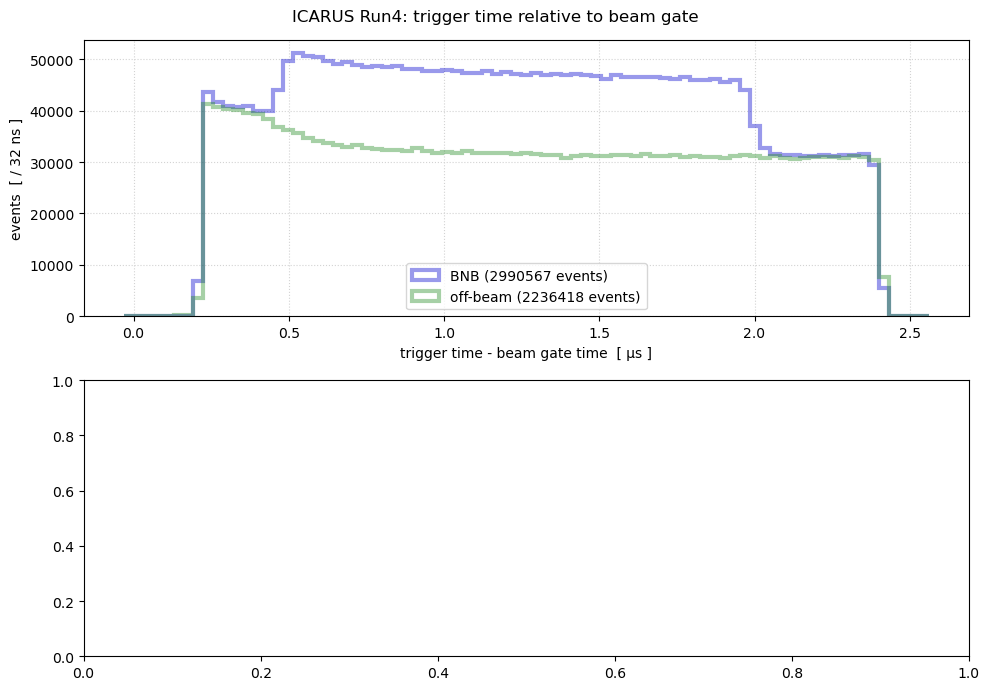

In [34]:
BeamBinnings = {
    'BNB': {  'range': ( 0.064*-0.5, 0.064*40.5 ), 'binWidth': 0.032, },
    'NuMI': { 'range': ( 0.256*-0.5, 0.256*16.5 ), 'binWidth': 0.032, },
}

fig, axes = plt.subplots(len(SignalBeams), layout='tight', squeeze=False, figsize=(10.0, 3.5 * len(SignalBeams)))
itAxis = iter(axes)
for iBeam, beamName in enumerate(SignalBeams):
    beamInfo = BeamInfo[beamName]
    binningInfo = BeamBinnings[beamName]

    periodData = TrigDB[(TrigDB.trigger_type == 0) & TrigDB.run_number.between(RunPeriod['firstRun'], RunPeriod['lastRun'])]

    data = periodData[periodData.gate_type == beamInfo['sourceIndex']]
    if len(data) == 0: continue
    ax = next(itAxis)[0]
    
    bins = numpy.arange(binningInfo['range'][0], binningInfo['range'][1], binningInfo['binWidth']) + 0.001
    offbeamName = beamName + 'offbeam'
    
    plotData = data.triggerFromBeamGate/1e3 - beamInfo['veto']
    artists = ax.hist(
        plotData, bins=bins,
        histtype="step",
        color=beamInfo['color'],
        label=f"{beamInfo['name']} ({len(plotData)} events)",
        )[2]
    artists[0].set(linewidth=3.0)

    try:
        offbeamInfo = BeamInfo[beamName + 'offbeam']
    except KeyError: pass
    else:
        bkgrData = periodData[periodData.gate_type == offbeamInfo['sourceIndex']]
        plotBkgrData = bkgrData.triggerFromBeamGate/1e3 - offbeamInfo['veto']
        artists = ax.hist(
            plotBkgrData, bins=bins,
            histtype="step",
            color=offbeamInfo['color'],
            label=f"off-beam ({len(plotBkgrData)} events)",
            )[2]
        artists[0].set(linewidth=3.0)
    # off-beam
    
    ax.set(
        xlabel="trigger time - beam gate time  [ µs ]",
        ylabel=f"events  [ / {binningInfo['binWidth']*1_000:g} ns ]",
    )
    # ax.axvline(0.5)
    
    ax.grid(color='lightgray', ls=':')
    ax.legend()
    print(f"{beamInfo['name']} range: {min(plotData)*1000} to {max(plotData)*1000} ns")
fig.suptitle(f"{RunPeriod['name']}: trigger time relative to beam gate")
savefig("TriggerTimeInBeamGate", fig)

BNB range: -2.33583e+08 to 2336 ns
NuMI range: -1.68639e+09 to 10232 ns
BNB range: 144 to 2424 ns
NuMI range: 152 to 11224 ns
BNB range: 144 to 2424 ns
BNB range: 144 to 2424 ns
BNB range: 216 to 2416 ns
NuMI range: 216 to 11216 ns
BNB range: 144 to 2424 ns
NuMI range: 152 to 11224 ns


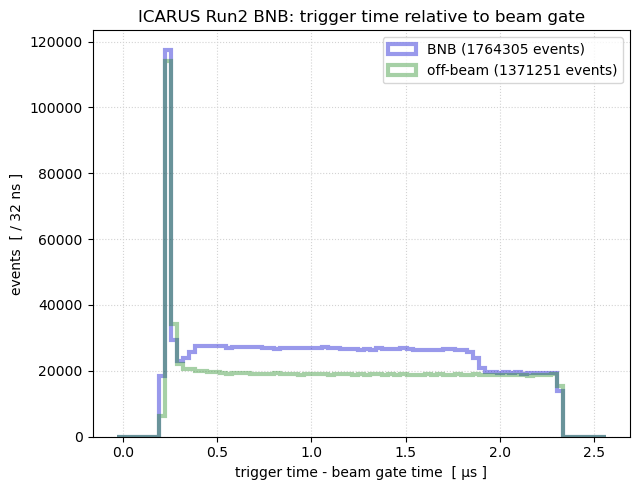

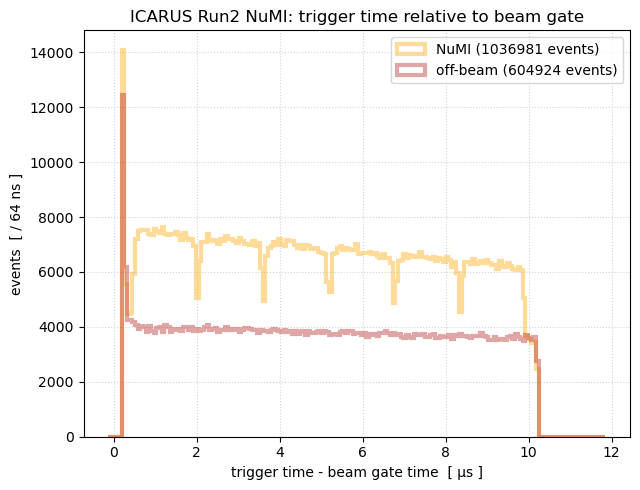

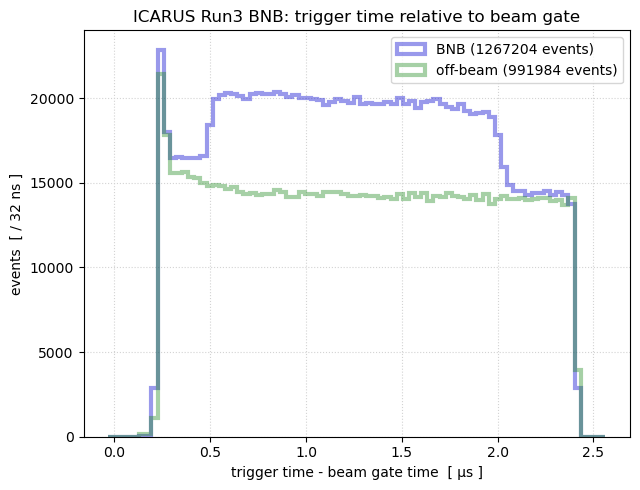

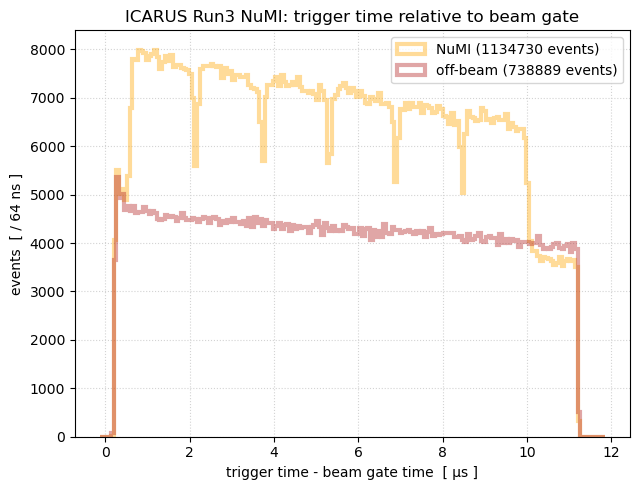

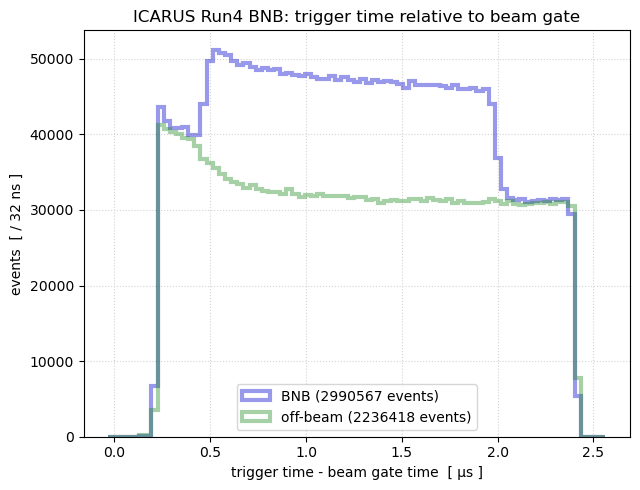

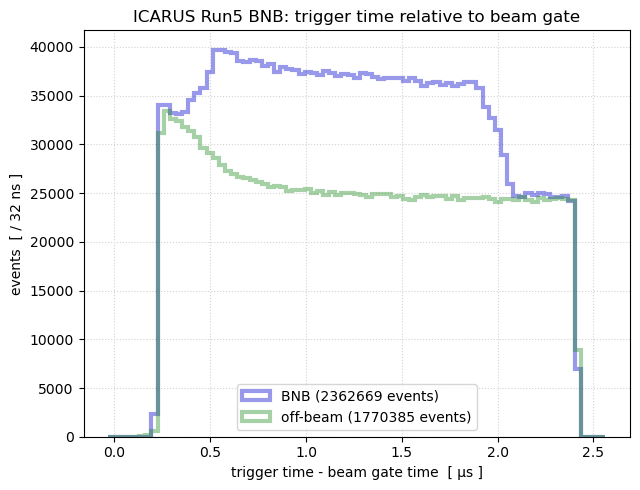

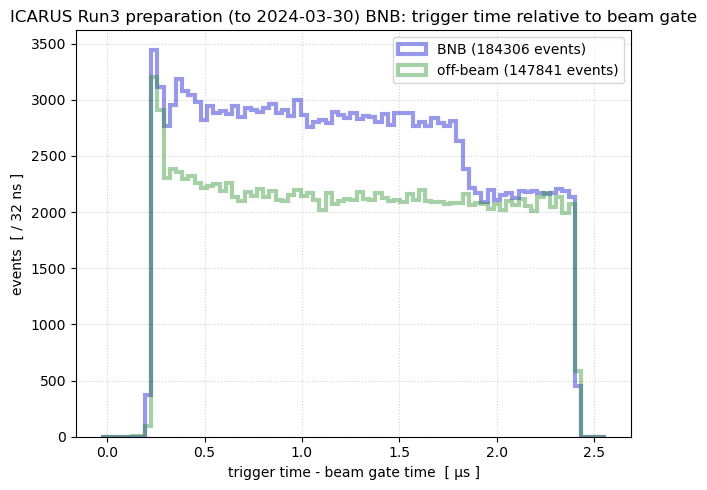

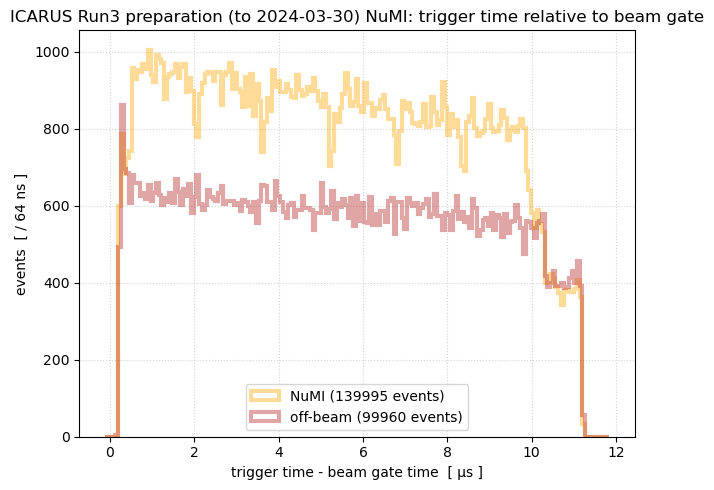

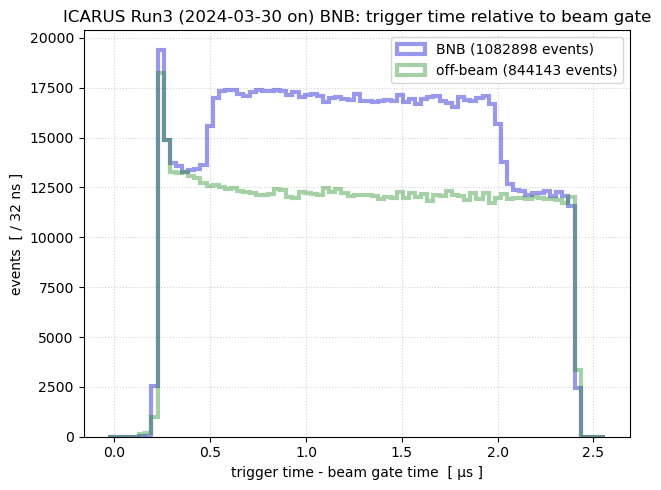

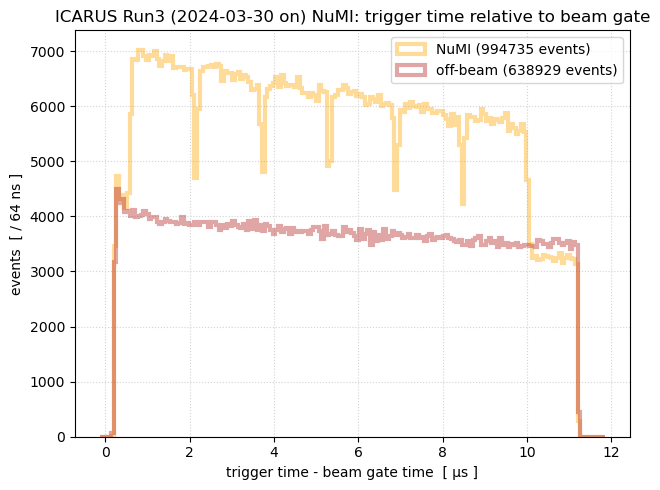

In [35]:
for RunPeriod in RunPeriods.values():
    RunTag = RunPeriod['tag']
    BeamBinnings = {
        'BNB': {  'range': ( 0.064*-0.5, 0.064*40.5 ), 'binWidth': 0.032, },
        'NuMI': { 'range': ( 0.256*-0.5, 0.256*46.5 ), 'binWidth': 0.064, },
    }
    
    for iBeam, beamName in enumerate(SignalBeams):
        beamInfo = BeamInfo[beamName]
        binningInfo = BeamBinnings[beamName]
    
        periodData = TrigDB[(TrigDB.trigger_type == 0) & TrigDB.run_number.between(RunPeriod['firstRun'], RunPeriod['lastRun'])]
    
        data = periodData[periodData.gate_type == beamInfo['sourceIndex']]
        if len(data) == 0: continue
        fig, ax = plt.subplots(layout='tight', figsize=(6.5, 5.0))
        
        bins = numpy.arange(binningInfo['range'][0], binningInfo['range'][1], binningInfo['binWidth']) + 0.001
        offbeamName = beamName + 'offbeam'
        
        plotData = data.triggerFromBeamGate/1e3 - beamInfo['veto']
        artists = ax.hist(
            plotData, bins=bins,
            histtype="step",
            color=beamInfo['color'],
            label=f"{beamInfo['name']} ({len(plotData)} events)",
            )[2]
        artists[0].set(linewidth=3.0)
    
        try:
            offbeamInfo = BeamInfo[beamName + 'offbeam']
        except KeyError: pass
        else:
            bkgrData = periodData[periodData.gate_type == offbeamInfo['sourceIndex']]
            plotBkgrData = bkgrData.triggerFromBeamGate/1e3 - offbeamInfo['veto']
            artists = ax.hist(
                plotBkgrData, bins=bins,
                histtype="step",
                color=offbeamInfo['color'],
                label=f"off-beam ({len(plotBkgrData)} events)",
                )[2]
            artists[0].set(linewidth=3.0)
        # off-beam
        
        ax.set(
            title=f"{RunPeriod['name']} {beamInfo['name']}: trigger time relative to beam gate",
            xlabel="trigger time - beam gate time  [ µs ]",
            ylabel=f"events  [ / {binningInfo['binWidth']*1_000:g} ns ]",
        )
        # ax.axvline(0.5)
        
        ax.grid(color='lightgray', ls=':')
        ax.legend()
        print(f"{beamInfo['name']} range: {min(plotData)*1000:g} to {max(plotData)*1000:g} ns")
        savefig(f"TriggerTimeInBeamGate-{beamInfo['name']}", fig)
    # for beam
# for period